In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

from mis_dro.plot import *
from mis_dro.experiments import ExperimentName
from mis_dro.results import preprocess_results_df, is_minimise_pareto_front, get_agg_df, get_result_df_list, convert_str_to_float_list


# from matplotlib import rc
# rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], "size":14})
# rc('text', usetex=True)

In [2]:
experiment_name = ExperimentName.kl_newsvendor_1d
# experiment_dir = Path(f"/Users/patrick/experiments/misdro/2025_01_21_paper_bas_experiments/{experiment_name.value}")
experiment_dir = Path(f"/dcs/large/u1508153/misdro/2025_01_21_paper_bas_experiments/{experiment_name.value}")
all_results_df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])

In [3]:
filter_dgp = "normal"  # filter by DGP
results_df = preprocess_results_df(all_results_df, filter_dgp)
# results_df = preprocess_results_df(all_results_df, filter_dgp)
results_df.head(3)

solution  \
uuid                                 replication                         
10aee0fd-c2c4-448d-995a-b307828a920e 0            [26.504853109137507]   
                                     1            [29.879991219010936]   
                                     2             [34.51079683893437]   

                                                  dgp_time  likelihood_time  \
uuid                                 replication                              
10aee0fd-c2c4-448d-995a-b307828a920e 0            0.000326         0.000119   
                                     1            0.000213         0.000081   
                                     2            0.000233         0.000085   

                                                  posterior_time  solve_time  \
uuid                                 replication                               
10aee0fd-c2c4-448d-995a-b307828a920e 0                  0.000081    0.042336   
                                     1                  0.000053    0.027507   
                                     2                  0.000055    0.025118   

                                                  setup_time  \
uuid                                 replication               
10aee0fd-c2c4-448d-995a-b307828a920e 0                   NaN   
                                     1                   NaN   
                                     2                   NaN   

                                                  log_partition_constant  \
uuid                                 replication                           
10aee0fd-c2c4-448d-995a-b307828a920e 0                               0.0   
                                     1                               0.0   
                                     2                               0.0   

                                                                                 out_of_sample_cost  \
uuid                                 replication                                                      
10aee0fd-c2c4-448d-995a-b307828a920e 0            [8.370599215733552, 97.27825277087481, 24.4703...   
                                     1            [14.395708241482502, 22.90806081601392, 64.485...   
                                     2            [3.288441345698814, 22.89133790738252, 18.6152...   

                                                 algorithm  contamination  \
uuid                                 replication                            
10aee0fd-c2c4-448d-995a-b307828a920e 0               kl_pp            0.0   
                                     1               kl_pp            0.0   
                                     2               kl_pp            0.0   

                                                  ... num_observations  \
uuid                                 replication  ...                    
10aee0fd-c2c4-448d-995a-b307828a920e 0            ...               20   
                                     1            ...               20   
                                     2            ...               20   

                                                 num_posterior_samples  \
uuid                                 replication                         
10aee0fd-c2c4-448d-995a-b307828a920e 0                               1   
                                     1                               1   
                                     2                               1   

                                                  num_replications  \
uuid                                 replication                     
10aee0fd-c2c4-448d-995a-b307828a920e 0                         500   
                                     1                         500   
                                     2                         500   

                                                  num_test_observations  \
uuid                                 replication                          
10aee0fd-c2c4-448d-995a-b307828a920e 0         

In [13]:
cv_kl_newsvendor_dir = Path("/dcs/large/u1508153/misdro/cv_kl_newsvendor_1d")
cv_kl_newsvendor_df = pd.read_csv(cv_kl_newsvendor_dir / "results.csv", index_col=["uuid", "replication"])
cv_df = cv_kl_newsvendor_df.loc[cv_kl_newsvendor_df["use_cv_epsilon"]]
cv_df = preprocess_results_df(cv_df, filter_dgp, dataset="newsvendor")
cv_agg_df = get_agg_df(cv_df, ["algorithm", "num_total_samples"])
cv_agg_df

/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/results.py:65: FutureWarning: The provided callable <function mean at 0x7f26a4135800> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/results.py:65: FutureWarning: The provided callable <function std at 0x7f26a4135940> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_df = gb.agg(


out_of_sample_mean  out_of_sample_var  \
algorithm  num_total_samples                                          
kl_bdro    25                          38.769220         848.807382   
           100                         37.373905         766.482024   
           900                         37.009679         763.187312   
kl_dro_bas 25                          39.007306         851.753209   
           100                         37.687922         769.082171   
           900                         37.012596         757.395108   
kl_pp      25                          38.733814         835.108310   
           100                         37.695214         770.999502   
           900                         36.973035         760.255962   

                              sum_of_in_group_var  var_of_in_group_mean  \
algorithm  num_total_samples                                              
kl_bdro    25                          823.330108             25.477274   
           100                         751.520528             14.961495   
           900                         748.480869             14.706443   
kl_dro_bas 25                          816.911810             34.841399   
           100                         753.626989             15.455181   
           900                         743.220199             14.174908   
kl_pp      25                          807.192831             27.915478   
           100                         751.211853             19.787650   
           900                         745.717706             14.538256   

                              mean_solve_time  std_solve_time  \
algorithm  num_total_samples                                    
kl_bdro    25                        0.068337        0.010130   
           100                       0.146614        0.019606   
           900                       0.718596        0.039714   
kl_dro_bas 25                        0.025491        0.004652   
           100                       0.037600        0.001313   
           900                       0.444853        0.019768   
kl_pp      25                        0.026355        0.011623   
           100                       0.038806        0.006603   
           900                       0.452111        0.020013   

                              mean_sample_time  std_sample_time  
algorithm  num_total_samples                                     
kl_bdro    25                         0.000118         0.000006  
           100                        0.000158         0.000006  
           900                        0.000331         0.000008  
kl_dro_bas 25                         0.000084         0.000228  
           100                        0.000069         0.000003  
           900                        0.000101         0.000005  
kl_pp      25                         0.000136         0.000012  
           100                        0.000139         0.000008  
           900                        0.000202         0.000009

In [5]:
# NOTE if you are visualising the 'num_observations' experiment, uncomment below line
# results_df = results_df.loc[(results_df["num_total_samples"] == 100) | (results_df["algorithm"] == "kl_empirical")]

In [9]:
agg_df = get_agg_df(results_df, ["algorithm", "dgp", "epsilon", "inference", "num_total_samples", "num_observations"])
agg_df

/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/results.py:65: FutureWarning: The provided callable <function mean at 0x7f26a4135800> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/results.py:65: FutureWarning: The provided callable <function std at 0x7f26a4135940> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_df = gb.agg(


out_of_sample_mean  \
algorithm dgp    epsilon inference num_total_samples num_observations                       
kl_bdro   normal 0.001   bayes     25                20                         39.210286   
                                   100               20                         37.910862   
                                   900               20                         37.555099   
                 0.002   bayes     25                20                         39.171374   
                                   100               20                         37.926581   
...                                                                                   ...   
kl_pp     normal 2.500   bayes     100               20                         48.180064   
                                   900               20                         54.951866   
                 3.000   bayes     25                20                         42.820576   
                                   100               20                         48.285827   
                                   900               20                         56.351574   

                                                                       out_of_sample_var  \
algorithm dgp    epsilon inference num_total_samples num_observations                      
kl_bdro   normal 0.001   bayes     25                20                       923.900937   
                                   100               20                       864.472885   
                                   900               20                       838.254272   
                 0.002   bayes     25                20                       924.516225   
                                   100               20                       862.524447   
...                                                                                  ...   
kl_pp     normal 2.500   bayes     100               20                       876.533561   
                                   900               20                       907.385324   
                 3.000   bayes     25                20                       921.079973   
                                   100               20                       883.276694   
                                   900               20                       934.356961   

                                                                       sum_of_in_group_var  \
algorithm dgp    epsilon inference num_total_samples num_observations                        
kl_bdro   normal 0.001   bayes     25                20                         890.666964   
                                   100               20                         841.225912   
                                   900               20                         817.627933   
                 0.002   bayes     25                20                         891.584082   
                                   100               20                         839.227196   
...                                                                                    ...   
kl_pp     normal 2.500   bayes     100               20                         728.978602   
                                   900               20                         746.206349   
                 3.000   bayes     25                20                         833.024792   
                                   100               20                         731.477542   
                                   900               20                         753.034263   

                                                                       var_of_in_group_mean  \
algorithm dgp    epsilon inference num_total_samples num_observations                         
kl_bdro   normal 0.001   bayes     25                20                           33.233973   
                                   100               20                           23.246974   
                                   900               20      

## Plot mean-variance trade-off

For each DGP, we plot the out-of-sample mean $\hat{\mu}_M(\epsilon)$ and variance $\hat{\sigma}_M(\epsilon)$ of Bayesian DRO with different posteriors.

All BDRO points are Pareto dominated for M = 25 ? True
All BDRO points are Pareto dominated for M = 100 ? True
All BDRO points are Pareto dominated for M = 900 ? False


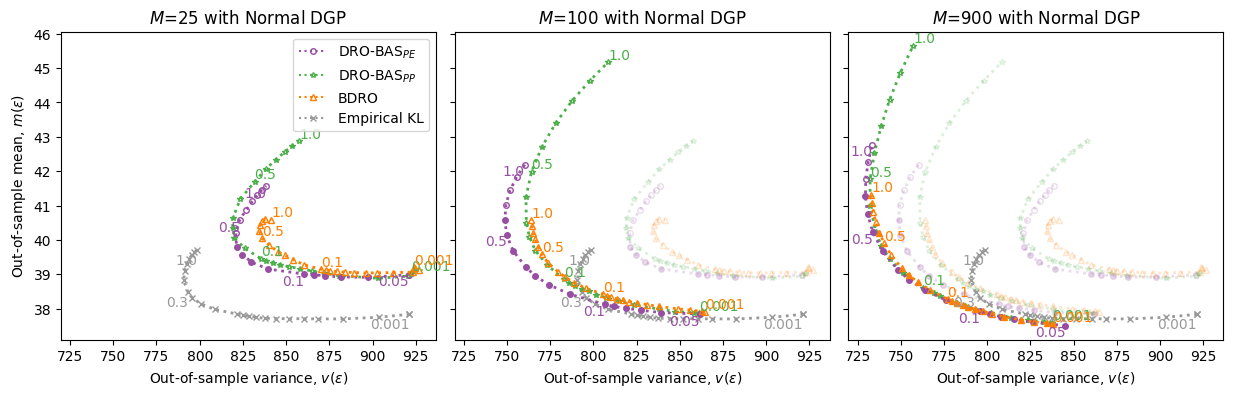

In [12]:
total_samples_list = agg_df.loc[~(agg_df.index.get_level_values("algorithm").isin(("kl_empirical", "wasserstein_empirical")))].index.get_level_values("num_total_samples").unique().tolist()
# num_observations_list = agg_df.index.get_level_values("num_observations").unique().tolist()
dgp_list = agg_df.index.get_level_values("dgp").unique().tolist()

nrows = len(dgp_list)
ncols = len(total_samples_list)
# ncols = len(num_observations_list)
trim_epsilon = 1.0

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(5*ncols, nrows*4))
fig.subplots_adjust(wspace=0.05)
pd.options.mode.chained_assignment = None  # default='warn'
for i, dgp in enumerate(dgp_list):
    for j, total_samples in enumerate(total_samples_list):
    # for j, num_observations in enumerate(num_observations_list):

        # NOTE empirical KL doesn't sample, so we plot it before filtering by total_samples
        mean_variance_plot(axes[j], agg_df.loc["kl_empirical", dgp, :trim_epsilon, "empirical", :, :], **algorithm_inference_style("kl_empirical", "empirical", label_inference=False), special_epsilons=[0.3], offset=0.1)
        # mean_variance_plot(axes[j], agg_df.loc["kl_empirical", dgp, :trim_epsilon, "empirical", num_observations, :], **algorithm_inference_style("kl_empirical", "empirical", label_inference=False), special_epsilons=[0.3], offset=0.1)
        # mean_variance_plot(axes[j], agg_df.loc["wasserstein_empirical", dgp, :, "empirical", :, :], **algorithm_inference_style("wasserstein_empirical", "empirical", label_inference=False), special_epsilons=[0.3], offset=0.1)


        # filter by the total samples and DGP
        axis_df = agg_df.loc[:, dgp, :, :, total_samples, :]
        # axis_df = agg_df.loc[:, dgp, :, :, :, num_observations]
        axis_df.loc[:, "is_pareto_front"] = is_minimise_pareto_front(axis_df["out_of_sample_var"].values, axis_df["out_of_sample_mean"].values)
        for algorithm, inference in set(zip(axis_df.index.get_level_values("algorithm"), axis_df.index.get_level_values("inference"))):
            df = axis_df.loc[algorithm, :trim_epsilon, :, :]

            if algorithm == "kl_bdro":
                print("All BDRO points are Pareto dominated for M =", total_samples, "?", not df["is_pareto_front"].any())


            for k in range(j, len(total_samples_list)):
            # for k in range(j, len(num_observations_list)):
                alpha = 1.0
                is_labelled=True
                if j != k:
                    alpha = 0.2
                    is_labelled = False
                mean_variance_plot(axes[k], df, **algorithm_inference_style(algorithm, inference, label_inference=False), offset=0.0, is_labelled=is_labelled, alpha=alpha)
        if j == 0:
            handles, labels = axes[j].get_legend_handles_labels()
            algorithm_order = [AlgorithmName.kl_dro_bas.value, AlgorithmName.kl_pp.value, AlgorithmName.kl_bdro.value, AlgorithmName.kl_empirical.value]
            # algorithm_order = [AlgorithmName.kl_dro_bas.value, AlgorithmName.kl_pp.value, AlgorithmName.kl_bdro.value, AlgorithmName.wasserstein_empirical.value]
            order = [list(labels).index(a) for a in algorithm_order]
            axes[j].legend([handles[idx] for idx in order],[labels[idx] for idx in order])
            axes[j].set_ylabel("Out-of-sample mean, $m(\epsilon)$")
        axes[j].set_title("$M$" + f"={total_samples} with {NiceNameDGP[filter_dgp]}")
        # axes[j].set_title("$n$" + f"={num_observations} with {NiceNameDGP[filter_dgp]}")
        axes[j].set_xlabel("Out-of-sample variance, $v(\epsilon)$")

# fig.savefig(f"/Users/patrick/Experiments/misdro/2025_01_21_paper_bas_experiments/{experiment_name}_{filter_dgp}_empirical.pdf", bbox_inches="tight")

## Solve & sampling time

In [ ]:
solve_time_df = get_agg_df(results_df, ["algorithm", "dgp", "num_total_samples"])[["mean_solve_time", "std_solve_time", "mean_sample_time", "std_sample_time"]]

decimal_places = 3
format_string = "{:.3f}"
solve_time_df["str_solve_time"] = solve_time_df[["mean_solve_time", "std_solve_time"]].apply(
    lambda x: format_string.format(np.round(x["mean_solve_time"], decimal_places)) + " (" + format_string.format(np.round(x["std_solve_time"], decimal_places)) + ")", axis=1
)
solve_time_df["str_sample_time"] = solve_time_df[["mean_sample_time", "std_sample_time"]].apply(
    lambda x: format_string.format(np.round(1000 * x["mean_sample_time"], decimal_places)) + " (" + format_string.format(np.round(1000 * x["std_sample_time"], decimal_places)) + ")", axis=1
)
# solve_time_df.reindex(pd.MultiIndex.from_product(np.repeat(["kl_dro_bas", "kl_pp", "kl_bdro", "kl_empirical"], 3), solve_time_df.index.get_level_values("num_total_samples"), names=['algorithm', 'num_total_samples']))
# solve_time_df = solve_time_df.reindex(["kl_dro_bas", "kl_pp", "kl_bdro", "kl_empirical"])
# solve_time_df.index = solve_time_df.index.map(lambda x: AlgorithmName[x].value)
print(solve_time_df[["str_solve_time", "str_sample_time"]].unstack(level="algorithm").reindex(columns=pd.MultiIndex.from_product([["str_solve_time", "str_sample_time"], ["kl_dro_bas", "kl_pp", "kl_bdro"]])).to_latex())

\begin{tabular}{llllllll}
\toprule
 &  & \multicolumn{3}{r}{str_solve_time} & \multicolumn{3}{r}{str_sample_time} \\
 &  & kl_dro_bas & kl_pp & kl_bdro & kl_dro_bas & kl_pp & kl_bdro \\
dgp & num_total_samples &  &  &  &  &  &  \\
\midrule
\multirow[t]{4}{*}{exponential} & 20 & NaN & NaN & NaN & NaN & NaN & NaN \\
 & 25 & 0.024 (0.003) & 0.024 (0.003) & 0.068 (0.012) & 0.097 (0.007) & 0.117 (0.009) & 0.360 (0.018) \\
 & 100 & 0.036 (0.003) & 0.037 (0.003) & 0.148 (0.020) & 0.099 (0.007) & 0.122 (0.015) & 0.614 (0.045) \\
 & 900 & 0.422 (0.030) & 0.428 (0.032) & 0.724 (0.040) & 0.114 (0.010) & 0.155 (0.013) & 1.611 (0.117) \\
\cline{1-8}
\bottomrule
\end{tabular}



/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:219: FutureWarning: The provided callable <function mean at 0x7fa0d8329940> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:219: FutureWarning: The provided callable <function std at 0x7fa0d8329a80> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_df = gb.agg(


# Plot sum of in-group variance and variance of in-group mean
Let $m$ be the number of test observations.
Let $k$ be the number of replications.
Let $\xi_{ij}$ be the $i^{\text{th}}$ test observation for replication $j$.
For a given replication $j$, the in-group mean and variance is
$$\mu_j = \frac{1}{m}\sum_{i=1}^m f(x_j, \xi_{ij}), \hspace{2em} v_j = \frac{1}{m-1}\sum_{i=1}^m \left( f(x_j, \xi_{ij}) - \mu_j \right)^2$$

We define the mean across all replications and all test observations as
$$\bar{\mu} = \frac{1}{mk} \sum_{j=1}^k \sum_{i=1}^m f(x_j, \xi_{ij}).$$

The total variance is defined by $$\frac{1}{mk-1}\sum_{j=1}^k \sum_{i=1}^m \left( f(x_j, \xi_{ij}) - \bar{\mu} \right)^2.$$
This can be decomposed into two terms.
The first is a constant times the sum of the in-group variances:
$$\frac{m-1}{km - 1} \sum^k_{j=1} v_j,$$
and the second term is a constant times the variance of the in-group means:
$$\frac{m(k-1)}{km - 1} \text{Var}(\mu_j).$$


KeyError: 25

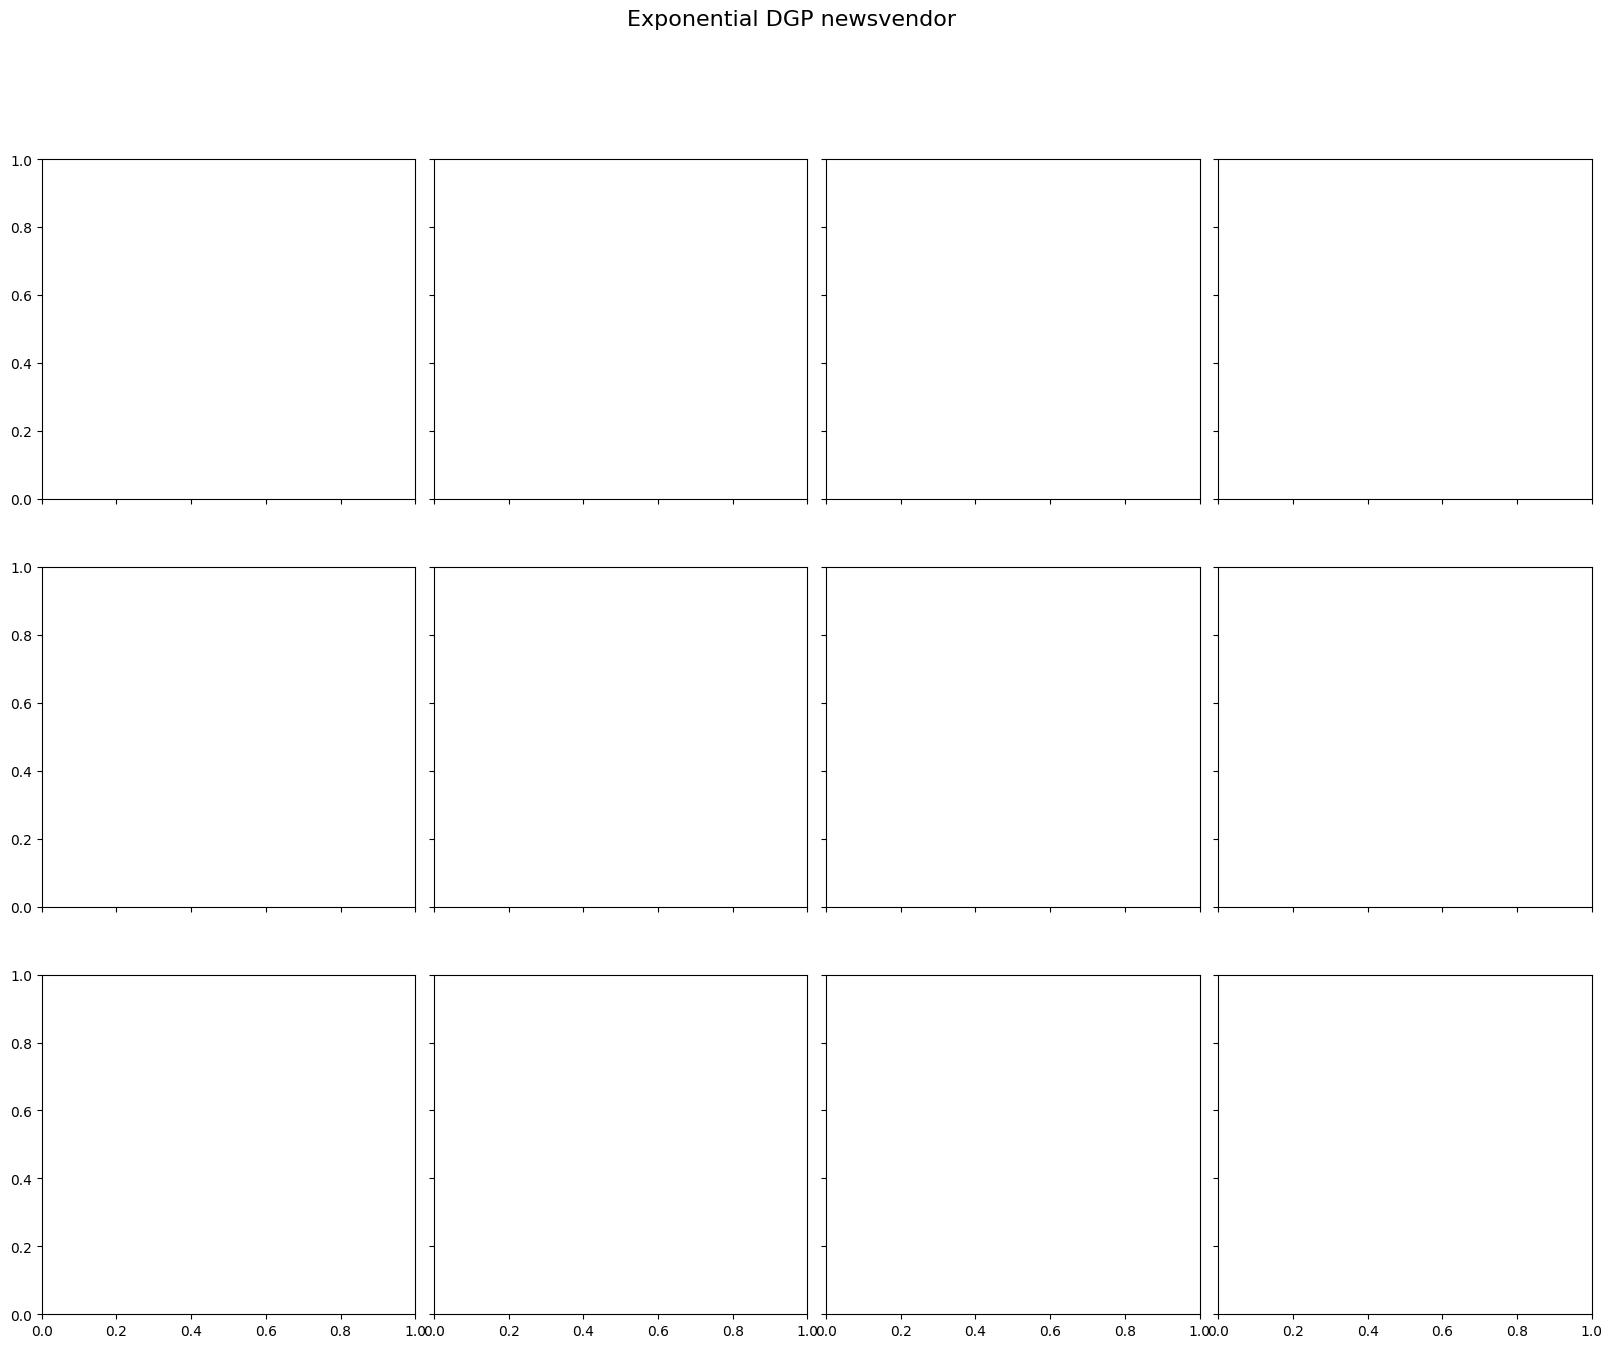

In [ ]:
total_samples_list = agg_df.index.get_level_values("num_total_samples").unique().tolist()
dgp_list = agg_df.index.get_level_values("dgp").unique().tolist()

nrows = 3
ncols = len(total_samples_list)
trim_epsilon = 1.0

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(5*ncols, nrows*5))
fig.subplots_adjust(wspace=0.05)
pd.options.mode.chained_assignment = None  # default='warn'
fig.suptitle(f"{NiceNameDGP[filter_dgp]} newsvendor", fontsize=16)

nice_var_names = {
    "out_of_sample_var": "Total variance",
    "sum_of_in_group_var": r"$\frac{m-1}{km - 1} \sum^k_{j=1} v_j$",
    "var_of_in_group_mean": r"$\frac{m(k-1)}{km - 1} \text{Var}(\mu_j)$",
}

for i, var_col in enumerate(["out_of_sample_var", "sum_of_in_group_var", "var_of_in_group_mean"]):
    for j, total_samples in enumerate(total_samples_list):
        axis_df = agg_df.loc[:, dgp, :trim_epsilon, total_samples]
        axis_df.loc[:, "is_pareto_front"] = is_minimise_pareto_front(axis_df["out_of_sample_var"].values, axis_df["out_of_sample_mean"].values)
        for algorithm in axis_df.index.get_level_values("algorithm").unique():
            df = axis_df.loc[algorithm, :]
            alpha = 1.0
            is_labelled=True
            mean_variance_plot(axes[i][j], df, **algorithm_inference_style(algorithm, "bayes", label_inference=False), offset=0.0, is_labelled=is_labelled, alpha=alpha, var_col=var_col)
        if j == 0:
            axes[i][j].legend()
            axes[i][j].set_ylabel("Out-of-sample mean")
        axes[i][j].set_title(nice_var_names[var_col] + " for $M$" + f"={total_samples}")
        axes[i][j].set_xlabel("Out-of-sample variance")

# fig.savefig(f"/Users/patrick/Experiments/misdro/paper_bas_figures/{experiment_name}_{filter_dgp}.pdf", bbox_inches="tight")

# Look at the solution

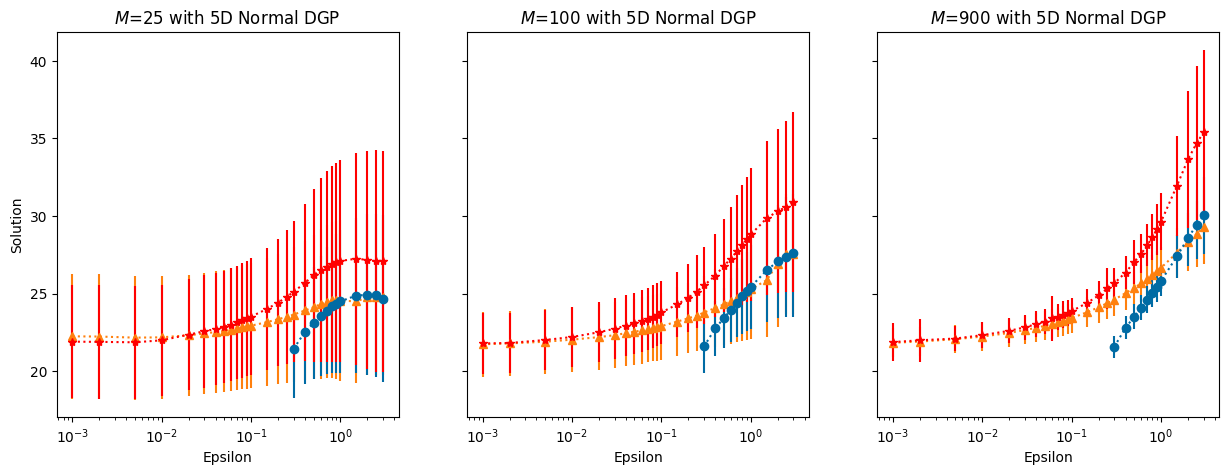

In [ ]:
df = results_df.copy()
df["solution"] = df["solution"].map(lambda x: x[4])
nrows = len(dgp_list)
ncols = len(total_samples_list)
fig, axes = plt.subplots(ncols=ncols, nrows=nrows, sharex=True, sharey=True, figsize=(5*ncols, nrows*5))
solution_df = df.groupby(["algorithm", "dgp", "epsilon", "num_total_samples"]).agg({"solution": ["mean", "std"]})
for i, dgp in enumerate(dgp_list):
    for j, total_samples in enumerate(total_samples_list):
        axis_df = solution_df.loc[:, dgp, :, total_samples]
        for algorithm in axis_df.index.get_level_values("algorithm").unique():
            axes[j].errorbar(axis_df.loc[algorithm, :].index.get_level_values("epsilon"), axis_df.loc[algorithm, :]["solution"]["mean"], yerr=axis_df.loc[algorithm, :]["solution"]["std"], **algorithm_inference_style(algorithm, "bayes"))
        axes[j].set_xscale("log")
        axes[j].set_title("$M$" + f"={total_samples} with {NiceNameDGP[filter_dgp]}")
        axes[j].set_xlabel("Epsilon")
        if j == 0:
            axes[j].set_ylabel("Solution")